In [5]:
import pandas as pd

df = pd.read_csv("../data/features_onehot/virus_cleavage_11mer_dataset.csv")
print(df.head())
print("Total samples:", len(df))

           protein_id  position       window  label
0      UniProt:P59594       257  FVGYLKPTTFM      1
1       NCBI:P59641.2      3606  AMLLVKHKHAF      1
2       NCBI:P15059.2       303  ATCALVSDCAS      1
3     NCBI:AAL01351.1        88  SEYRHYCYSLY      1
4  UniProt:A0A087VSD2       800  TGLWSLALLVL      1
Total samples: 72679


In [6]:
sequences = df["window"]
labels = df["label"]

In [7]:
import numpy as np

amino_acids = "ACDEFGHIKLMNPQRSTVWY"

def aa_frequency(seq):
    length = len(seq)
    return [seq.count(aa)/length for aa in amino_acids]

X_freq = np.array([aa_frequency(s) for s in sequences])

In [8]:
aa_to_index = {aa:i for i,aa in enumerate(amino_acids)}

def one_hot(seq):
    mat = np.zeros((len(seq),20))
    for i,aa in enumerate(seq):
        if aa in aa_to_index:
            mat[i, aa_to_index[aa]] = 1
    return mat.flatten()

X_onehot = np.array([one_hot(s) for s in sequences])

In [9]:
X = np.concatenate([X_onehot, X_freq], axis=1)
y = labels.values

print("Feature matrix shape:", X.shape)

Feature matrix shape: (72679, 240)


In [10]:
import numpy as np

np.save("../data/features_onehot/X_onehot_freq.npy", X)
np.save("../data/features_onehot/y_labels.npy", y)

print("Files saved successfully")

Files saved successfully


In [11]:
import pandas as pd

pd.DataFrame(X).to_csv("../data/features_onehot/X_onehot_freq.csv", index=False)
pd.Series(y).to_csv("../data/features_onehot/y_labels.csv", index=False)

In [12]:
import numpy as np

X = np.load("../data/features_onehot/X_onehot_freq.npy")
y = np.load("../data/features_onehot/y_labels.npy")

print(X.shape)

(72679, 240)


In [13]:
X

array([[0.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.09090909],
       [1.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.        ],
       [1.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.18181818],
       [0.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.18181818],
       [0.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.18181818]], shape=(72679, 240))

In [14]:
print(X.shape)
print(y.shape)

(72679, 240)
(72679,)


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/features_onehot/virus_cleavage_11mer_dataset.csv")

# unique proteins
proteins = df["protein_id"].unique()

train_prot, test_prot = train_test_split(
    proteins,
    test_size=0.20,
    random_state=42
)

In [16]:
train_df = df[df["protein_id"].isin(train_prot)]
test_df  = df[df["protein_id"].isin(test_prot)]

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

Train samples: 55292
Test samples: 17387


In [17]:
set(train_df["protein_id"]) & set(test_df["protein_id"])

set()

In [18]:
X_train = X[train_df.index]
y_train = y[train_df.index]

X_test = X[test_df.index]
y_test = y[test_df.index]

In [19]:
train_df.to_csv("../data/features_onehot/train_dataset.csv", index=False)
test_df.to_csv("../data/features_onehot/test_dataset.csv", index=False)

In [20]:
import numpy as np

np.save("../data/features_onehot/X_train.npy", X_train)
np.save("../data/features_onehot/X_test.npy", X_test)

np.save("../data/features_onehot/y_train.npy", y_train)
np.save("../data/features_onehot/y_test.npy", y_test)

In [21]:
import numpy as np

X_train = np.load("../data/features_onehot/X_train.npy")
y_train = np.load("../data/features_onehot/y_train.npy")

In [23]:
X_train

array([[1.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.        ],
       [1.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.36363636],
       ...,
       [0.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.09090909],
       [1.        , 0.        , 0.        , ..., 0.09090909, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.27272727, 0.18181818,
        0.09090909]], shape=(55292, 240))

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

In [25]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}
Best CV score: 0.7699008768966475


In [27]:
from sklearn.metrics import roc_auc_score

X_test = np.load("../data/features_onehot/X_test.npy")
y_test = np.load("../data/features_onehot/y_test.npy")

pred = best_model.predict_proba(X_test)[:,1]

print("Test ROC-AUC:", roc_auc_score(y_test, pred))

Test ROC-AUC: 0.804242233642441


In [28]:
import joblib

joblib.dump(best_model, "../models/rf_gridsearch_model.pkl")

['../models/rf_gridsearch_model.pkl']

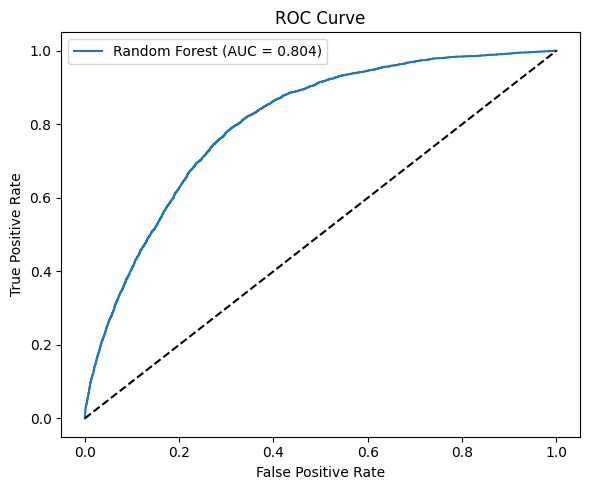

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_pred_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

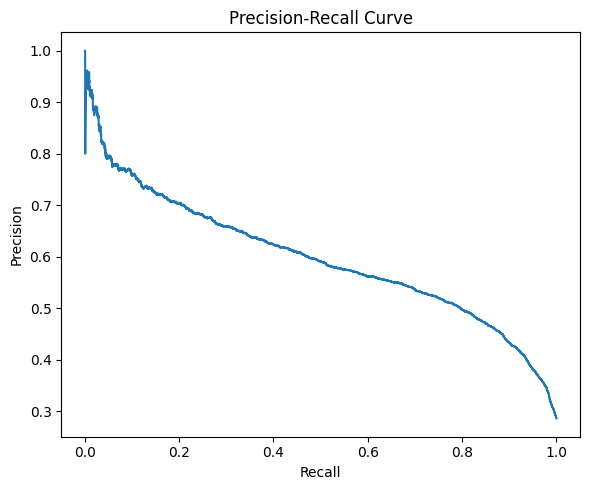

In [30]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

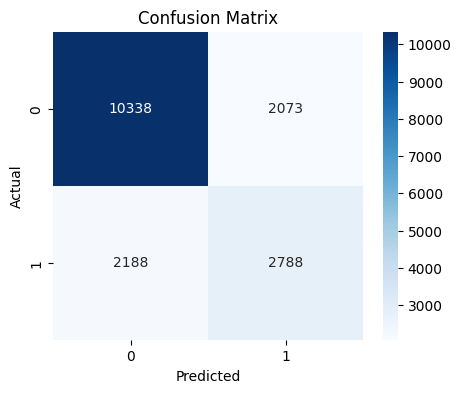

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

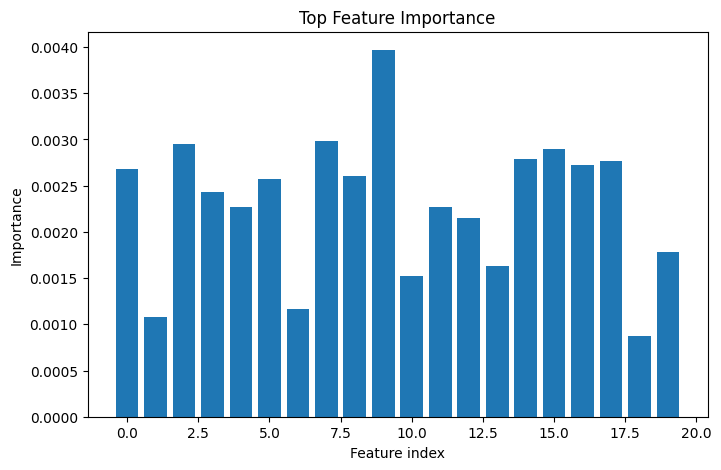

In [32]:
import pandas as pd

importance = best_model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(range(20), importance[:20])

plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.title("Top Feature Importance")

plt.show()

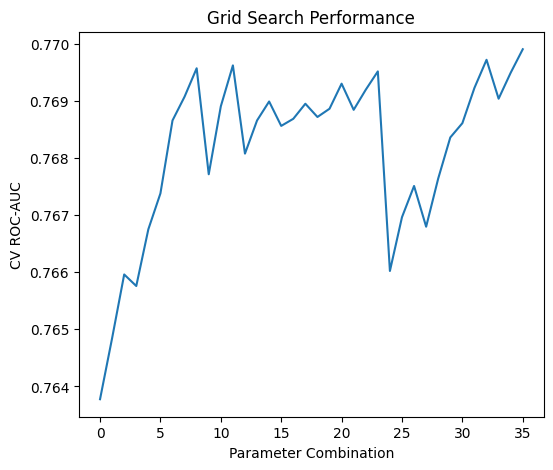

In [33]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(6,5))
plt.plot(results["mean_test_score"])

plt.xlabel("Parameter Combination")
plt.ylabel("CV ROC-AUC")
plt.title("Grid Search Performance")

plt.show()

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("matthews_corrcoef:", matthews_corrcoef(y_test, y_pred))

Accuracy: 0.7549318456317938
Precision: 0.5735445381608723
Recall: 0.5602893890675241
F1: 0.566839483582393
matthews_corrcoef: 0.39605407839087875


In [37]:
plt.savefig("../data/features_onehot/roc_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [38]:
from sklearn.metrics import roc_auc_score

best_model = grid.best_estimator_

y_prob = best_model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.804242233642441

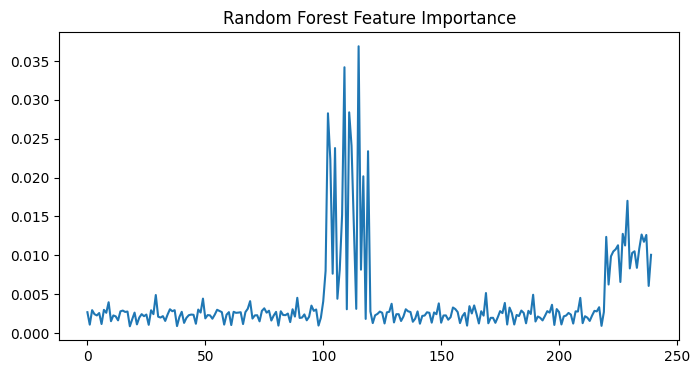

In [39]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_

plt.figure(figsize=(8,4))
plt.plot(importance)
plt.title("Random Forest Feature Importance")
plt.show()

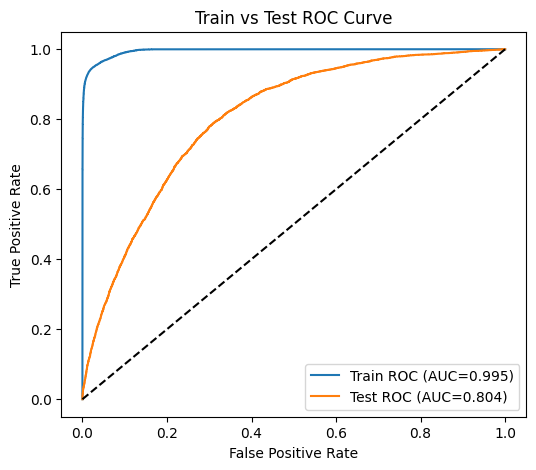

In [40]:
from sklearn.metrics import roc_curve, auc

# train probabilities
train_prob = best_model.predict_proba(X_train)[:,1]

# test probabilities
test_prob = best_model.predict_proba(X_test)[:,1]

fpr_train, tpr_train, _ = roc_curve(y_train, train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, test_prob)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6,5))

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC={auc_test:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Test ROC Curve")

plt.legend()
plt.show()

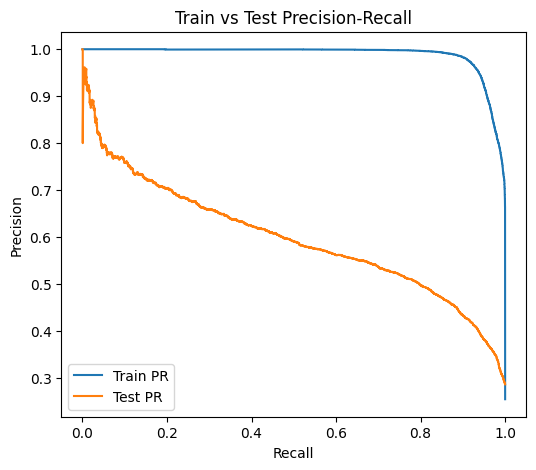

In [41]:
from sklearn.metrics import precision_recall_curve

precision_train, recall_train, _ = precision_recall_curve(y_train, train_prob)
precision_test, recall_test, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6,5))

plt.plot(recall_train, precision_train, label="Train PR")
plt.plot(recall_test, precision_test, label="Test PR")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Train vs Test Precision-Recall")

plt.legend()
plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83     12411
           1       0.57      0.56      0.57      4976

    accuracy                           0.75     17387
   macro avg       0.70      0.70      0.70     17387
weighted avg       0.75      0.75      0.75     17387



Train ROC-AUC: 0.9954711788686473
Test ROC-AUC : 0.804242233642441


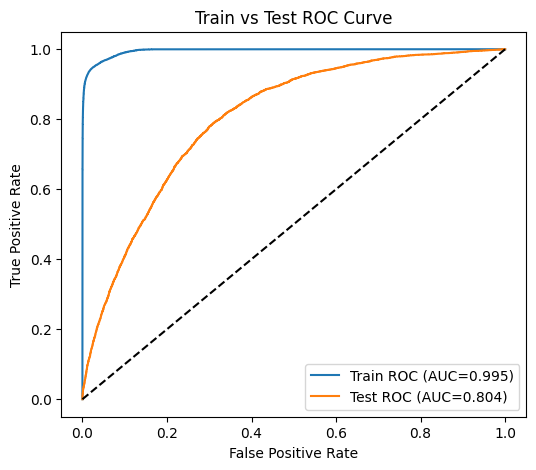

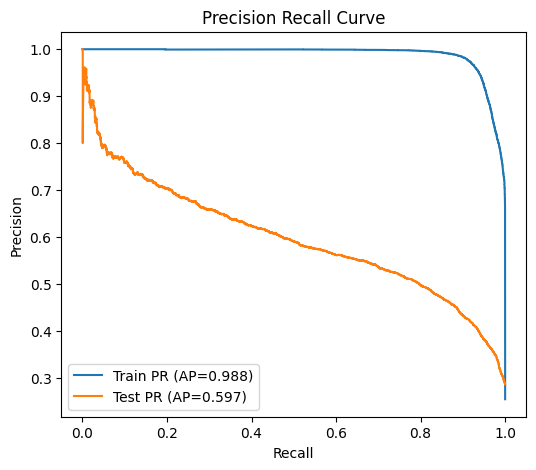

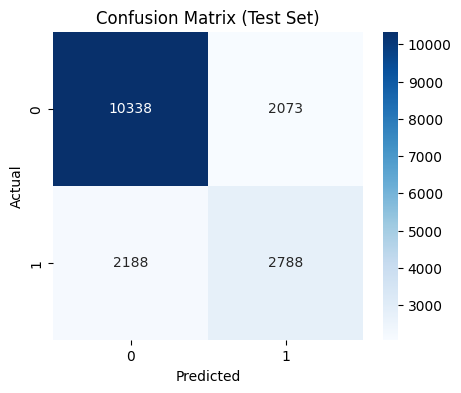


Classification Report (Test Set)

              precision    recall  f1-score   support

           0       0.83      0.83      0.83     12411
           1       0.57      0.56      0.57      4976

    accuracy                           0.75     17387
   macro avg       0.70      0.70      0.70     17387
weighted avg       0.75      0.75      0.75     17387

      Metric     Score
0   Accuracy  0.754932
1  Precision  0.573545
2     Recall  0.560289
3   F1-score  0.566839
4    ROC-AUC  0.804242


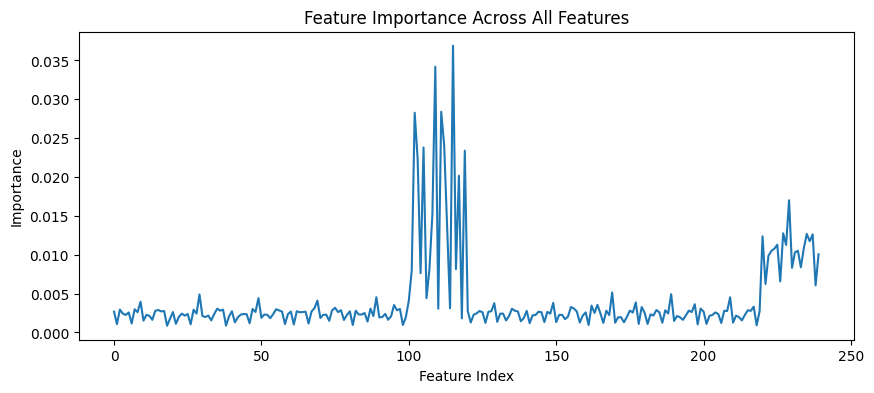

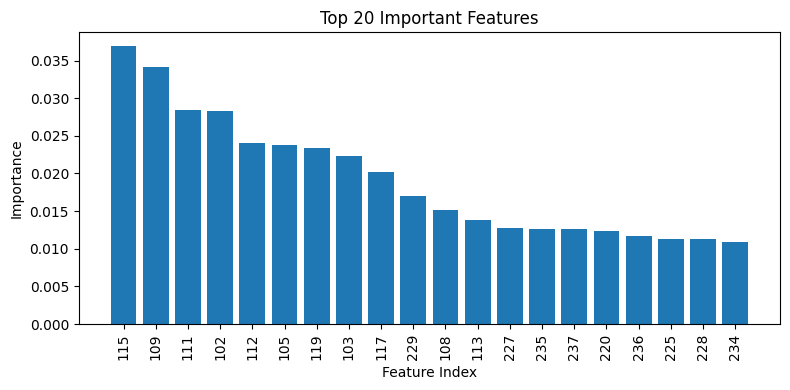


All plots saved in ../results/


In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------------
# Create results directory
# --------------------------------------------------

os.makedirs("../results", exist_ok=True)

# --------------------------------------------------
# Predictions
# --------------------------------------------------

train_probs = best_model.predict_proba(X_train)[:,1]
test_probs  = best_model.predict_proba(X_test)[:,1]

train_pred = best_model.predict(X_train)
test_pred  = best_model.predict(X_test)

# --------------------------------------------------
# ROC AUC
# --------------------------------------------------

train_auc = roc_auc_score(y_train, train_probs)
test_auc  = roc_auc_score(y_test, test_probs)

print("Train ROC-AUC:", train_auc)
print("Test ROC-AUC :", test_auc)

# --------------------------------------------------
# ROC Curve
# --------------------------------------------------

fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
fpr_test, tpr_test, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6,5))

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={train_auc:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC={test_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Train vs Test ROC Curve")
plt.legend()

plt.savefig("../results/roc_curve.png", dpi=300)
plt.show()

# --------------------------------------------------
# Precision Recall Curve
# --------------------------------------------------

precision_train, recall_train, _ = precision_recall_curve(y_train, train_probs)
precision_test, recall_test, _ = precision_recall_curve(y_test, test_probs)

ap_train = average_precision_score(y_train, train_probs)
ap_test  = average_precision_score(y_test, test_probs)

plt.figure(figsize=(6,5))

plt.plot(recall_train, precision_train, label=f"Train PR (AP={ap_train:.3f})")
plt.plot(recall_test, precision_test, label=f"Test PR (AP={ap_test:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.legend()

plt.savefig("../results/pr_curve.png", dpi=300)
plt.show()

# --------------------------------------------------
# Confusion Matrix (TEST ONLY)
# --------------------------------------------------

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")

plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

# --------------------------------------------------
# Classification Metrics
# --------------------------------------------------

print("\nClassification Report (Test Set)\n")

print(classification_report(y_test, test_pred))

acc = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred)
rec = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score","ROC-AUC"],
    "Score": [acc,prec,rec,f1,test_auc]
})

print(metrics_df)

metrics_df.to_csv("../results/model_metrics.csv",index=False)

# --------------------------------------------------
# Feature Importance
# --------------------------------------------------

importances = best_model.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(importances)

plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance Across All Features")

plt.savefig("../results/feature_importance.png", dpi=300)
plt.show()

# --------------------------------------------------
# Top 20 Features
# --------------------------------------------------

indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8,4))

plt.bar(range(20), importances[indices])

plt.xticks(range(20), indices, rotation=90)

plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Top 20 Important Features")

plt.tight_layout()

plt.savefig("../results/top20_features.png", dpi=300)
plt.show()

print("\nAll plots saved in ../results/")